In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu từ file CSV
df_raw = pd.read_csv('bank_data.csv')

In [31]:
# 2. Cấu trúc tổng thể
print("Shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())
print("\nData types:")
print(df_raw.dtypes)

Shape: (11162, 17)

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


In [32]:
# 3. In ra 10 dòng đầu tiên
df_raw.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
6,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
7,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
9,28,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes


In [33]:
# 4. Rà soát dữ liệu bị thiếu
print("Missing values per column:")
df_raw.isna().sum()

Missing values per column:


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [34]:
# 5. Tổng quát dữ liệu
display(df_raw.describe(include="all"))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,11162.000000,11162,11162,11162,11162,11162.000000,11162,11162,11162,11162.000000,11162,11162.000000,11162.000000,11162.000000,11162.000000,11162,11162
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,2566,6351,5476,10994,NaN,5881,9702,8042,NaN,2824,NaN,NaN,NaN,NaN,8326,5873
mean,41.231948,NaN,NaN,NaN,NaN,1528.538524,NaN,NaN,NaN,15.658036,NaN,371.993818,2.508421,51.330407,0.832557,NaN,NaN
std,11.913369,NaN,NaN,NaN,NaN,3225.413326,NaN,NaN,NaN,8.420740,NaN,347.128386,2.722077,108.758282,2.292007,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,32.000000,NaN,NaN,NaN,NaN,122.000000,NaN,NaN,NaN,8.000000,NaN,138.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,550.000000,NaN,NaN,NaN,15.000000,NaN,255.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1708.000000,NaN,NaN,NaN,22.000000,NaN,496.000000,3.000000,20.750000,1.000000,NaN,NaN


In [35]:
# 6. Tạo copy
df=df_raw.copy()
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [36]:
# 7. Kiểm tra và xóa dòng trùng lặp nếu có
duplicate_count = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Đã loại bỏ các dòng trùng lặp.")

Số dòng trùng lặp: 0


CLEANING AND STANDARDIZING DATA

In [37]:
# Xóa khoảng trắng ở đầu và cuối
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    df.loc[:, col] =df[col].astype(str).str.strip()

df[text_columns]

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
0,admin.,married,secondary,no,yes,no,unknown,may,unknown,yes
1,admin.,married,secondary,no,no,no,unknown,may,unknown,yes
2,technician,married,secondary,no,yes,no,unknown,may,unknown,yes
3,services,married,secondary,no,yes,no,unknown,may,unknown,yes
4,admin.,married,tertiary,no,no,no,unknown,may,unknown,yes
...,...,...,...,...,...,...,...,...,...,...
11157,blue-collar,single,primary,no,yes,no,cellular,apr,unknown,no
11158,services,married,secondary,no,no,no,unknown,jun,unknown,no
11159,technician,single,secondary,no,no,no,cellular,aug,unknown,no
11160,technician,married,secondary,no,no,yes,cellular,may,failure,no


In [38]:
# Chuẩn hoá tên 
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    df[col] = df[col].str.title()

df[text_columns]

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
0,Admin.,Married,Secondary,No,Yes,No,Unknown,May,Unknown,Yes
1,Admin.,Married,Secondary,No,No,No,Unknown,May,Unknown,Yes
2,Technician,Married,Secondary,No,Yes,No,Unknown,May,Unknown,Yes
3,Services,Married,Secondary,No,Yes,No,Unknown,May,Unknown,Yes
4,Admin.,Married,Tertiary,No,No,No,Unknown,May,Unknown,Yes
...,...,...,...,...,...,...,...,...,...,...
11157,Blue-Collar,Single,Primary,No,Yes,No,Cellular,Apr,Unknown,No
11158,Services,Married,Secondary,No,No,No,Unknown,Jun,Unknown,No
11159,Technician,Single,Secondary,No,No,No,Cellular,Aug,Unknown,No
11160,Technician,Married,Secondary,No,No,Yes,Cellular,May,Failure,No


In [39]:
# Xử lý lỗi chính tả 
df['job'] = df['job'].replace({'Admin.': 'Admin'})

In [49]:
# Thay đổi biến UNKNOWN trong poutcome thành New Customer

df['poutcome'] = df['poutcome'].replace('Unknown', 'New Customer')

/var/folders/j5/6jk78ny91tvfq027yv3l2pzh0000gn/T/ipykernel_45613/4252341262.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['poutcome'] = df['poutcome'].replace('Unknown', 'New Customer')


CORRECTING DATA TYPES


In [50]:
print(df.dtypes)

age             Int64
job          category
marital      category
education    category
default      category
balance         Int64
housing      category
loan         category
contact      category
day             Int64
month        category
duration        Int64
campaign        Int64
pdays           Int64
previous        Int64
poutcome     category
deposit      category
dtype: object


In [58]:
# 1. Ép kiểu các cột số
float_cols = ['age', 'balance', 'duration']
for col in float_cols:
    df[col] = df[col].astype('float64')

numeric_cols = ['day', 'campaign', 'pdays', 'previous']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# 2. Ép kiểu các cột phân loại
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 
                    'loan', 'contact', 'month', 'poutcome', 'deposit']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Kiểm tra lại dung lượng bộ nhớ
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        11162 non-null  float64 
 1   job        11162 non-null  category
 2   marital    11162 non-null  category
 3   education  11162 non-null  category
 4   default    11162 non-null  category
 5   balance    11162 non-null  float64 
 6   housing    11162 non-null  category
 7   loan       11162 non-null  category
 8   contact    11162 non-null  category
 9   day        11162 non-null  Int64   
 10  month      11162 non-null  category
 11  duration   11162 non-null  float64 
 12  campaign   11162 non-null  Int64   
 13  pdays      11162 non-null  Int64   
 14  previous   11162 non-null  Int64   
 15  poutcome   11162 non-null  category
 16  deposit    11162 non-null  category
dtypes: Int64(4), category(10), float64(3)
memory usage: 765.1 KB
None


DETECTING INVALID VALUES

In [59]:
# Kiểm tra các giá trị không hợp lệ 
invalid_rules = {
    "Tuổi ngoài khoảng (18-100)": df[(df['age'] < 18) | (df['age'] > 100)].shape[0],
    "Thời lượng cuộc gọi <= 0": df[df['duration'] <= 0].shape[0],
    "Số lần liên hệ (campaign) < 1": df[df['campaign'] < 1].shape[0],
    "Số ngày liên lạc trước đó (pdays) < -1": df[df['pdays'] < -1].shape[0]
}

print("-KIỂM TRA GIÁ TRỊ KHÔNG HỢP LỆ-")
for rule, count in invalid_rules.items():
    print(f"{rule}: {count} trường hợp")

-KIỂM TRA GIÁ TRỊ KHÔNG HỢP LỆ-
Tuổi ngoài khoảng (18-100): 0 trường hợp
Thời lượng cuộc gọi <= 0: 0 trường hợp
Số lần liên hệ (campaign) < 1: 0 trường hợp
Số ngày liên lạc trước đó (pdays) < -1: 0 trường hợp


In [60]:
# Kiểm tra Outliers cho cột 'balance' (Số dư tài khoản)
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

pd.to_numeric(df["balance"], errors="coerce")
outliers_balance = df[(df["balance"] < lower_bound) | (df["balance"] > upper_bound)]
print(f"\nSố lượng Outliers trong cột 'balance': {len(outliers_balance)}")
print(f"Ngưỡng Outliers: Dưới {lower_bound} hoặc Trên {upper_bound}")
outliers_balance


Số lượng Outliers trong cột 'balance': 1055
Ngưỡng Outliers: Dưới -2257.0 hoặc Trên 4087.0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
9,28.0,Services,Single,Secondary,No,5090.0,Yes,No,Unknown,6,May,1297.0,3,-1,0,New Customer,Yes
60,51.0,Blue-Collar,Married,Secondary,No,7180.0,Yes,No,Unknown,14,May,927.0,1,-1,0,New Customer,Yes
61,41.0,Blue-Collar,Divorced,Secondary,No,5291.0,Yes,No,Unknown,14,May,1423.0,3,-1,0,New Customer,Yes
69,44.0,Technician,Married,Tertiary,No,4580.0,Yes,No,Unknown,15,May,911.0,2,-1,0,New Customer,Yes
71,29.0,Management,Married,Tertiary,No,10576.0,No,No,Unknown,15,May,1224.0,2,-1,0,New Customer,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11073,34.0,Blue-Collar,Married,Primary,No,6718.0,No,No,Cellular,13,Jan,278.0,4,97,1,Other,No
11077,54.0,Retired,Divorced,Tertiary,No,6102.0,Yes,Yes,Unknown,21,May,86.0,6,-1,0,New Customer,No
11085,60.0,Technician,Married,Primary,No,4243.0,Yes,No,Cellular,4,Feb,387.0,1,251,1,Failure,No
11086,42.0,Admin,Married,Secondary,No,6445.0,Yes,No,Unknown,2,Jun,20.0,8,-1,0,New Customer,No


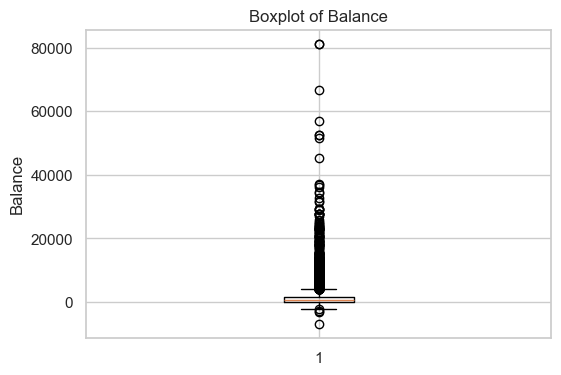

In [61]:
plt.figure(figsize=(6, 4))
plt.boxplot(df["balance"].dropna())
plt.title("Boxplot of Balance")
plt.ylabel("Balance")
plt.show()

RULE-BASED VALIDATION SUMMARY

In [62]:
# Định nghĩa các giá trị hợp lệ cho cột poutcome (ví dụ)
valid_poutcome = {"Success", "Failure", "Other", "Unknown", "New Customer"}

# Thực hiện kiểm tra tổng thể
validation_results = {
    "age_valid_range": df["age"].between(18, 100).all(),
    "balance_min_check": (df["balance"] >= -10000).all(),
    "duration_positive": (df["duration"] > 0).all(),
    "campaign_valid_range": df["campaign"].between(1, 100).all(),
    "poutcome_valid_values": df["poutcome"].astype(str).isin(valid_poutcome).all()
}

# Hiển thị kết quả
import pprint
pprint.pprint(validation_results)

{'age_valid_range': True,
 'balance_min_check': True,
 'campaign_valid_range': True,
 'duration_positive': True,
 'poutcome_valid_values': True}


COMPARE RAW DATA AND CLEAN DATA

In [63]:
print("Raw data:")
display(df_raw)
print("Cleaned data:")
display(df)

Raw data:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


Cleaned data:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59.0,Admin,Married,Secondary,No,2343.0,Yes,No,Unknown,5,May,1042.0,1,-1,0,New Customer,Yes
1,56.0,Admin,Married,Secondary,No,45.0,No,No,Unknown,5,May,1467.0,1,-1,0,New Customer,Yes
2,41.0,Technician,Married,Secondary,No,1270.0,Yes,No,Unknown,5,May,1389.0,1,-1,0,New Customer,Yes
3,55.0,Services,Married,Secondary,No,2476.0,Yes,No,Unknown,5,May,579.0,1,-1,0,New Customer,Yes
4,54.0,Admin,Married,Tertiary,No,184.0,No,No,Unknown,5,May,673.0,2,-1,0,New Customer,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33.0,Blue-Collar,Single,Primary,No,1.0,Yes,No,Cellular,20,Apr,257.0,1,-1,0,New Customer,No
11158,39.0,Services,Married,Secondary,No,733.0,No,No,Unknown,16,Jun,83.0,4,-1,0,New Customer,No
11159,32.0,Technician,Single,Secondary,No,29.0,No,No,Cellular,19,Aug,156.0,2,-1,0,New Customer,No
11160,43.0,Technician,Married,Secondary,No,0.0,No,Yes,Cellular,8,May,9.0,2,172,5,Failure,No


BUILD A REUSABLE CLEANING FUNCTION

In [64]:
import pandas as pd
import numpy as np

def clean_bank_dataset(df_input: pd.DataFrame) -> pd.DataFrame:
    df = df_input.copy()

    # 1. Chuẩn hóa các đại diện của giá trị thiếu (Missing values)
    # Chuyển tất cả về dạng np.nan để dễ dàng quản lý
    df = df.replace(["none", "None", "N/A", "unknown", ""], np.nan)

    # 2. Xử lý các cột văn bản (Categorical columns)
    categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 
                        'loan', 'contact', 'month', 'poutcome', 'deposit']

    for col in categorical_cols:
        if col in df.columns:
            # Xóa khoảng trắng thừa và chuẩn hóa viết hoa chữ cái đầu (Title Case)
            df[col] = df[col].astype(str).str.strip().str.title()
            
            # Xử lý riêng các giá trị Missing sau khi chuẩn hóa
            # Riêng poutcome có thể đổi Nan thành "New Customer"
            if col == 'poutcome':
                df[col] = df[col].replace('Nan', 'New Customer')
            else:
                df[col] = df[col].replace('Nan', 'Unknown')

    # 3. Ép kiểu dữ liệu về số thực cho các cột định lượng
    float_cols = ['age', 'balance', 'duration']
    for col in float_cols:
        df[col] = df[col].astype('float64')

    numeric_cols = ['day', 'campaign', 'pdays', 'previous']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    # 4. Tối ưu bộ nhớ bằng cách chuyển sang kiểu 'category'
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    return df

# Cách sử dụng
df_raw = pd.read_csv('bank_data.csv')
df_cleaned = clean_bank_dataset(df_raw)

In [65]:
# Xuất dữ liệu đã làm sạch ra file mới
df_cleaned.to_csv('bank_data_cleaned.csv', index=False)

print("Đã xuất file bank_data_cleaned.csv thành công!")

Đã xuất file bank_data_cleaned.csv thành công!
